In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score

# 1. Load the dataset
df = pd.read_csv('Invistico_Airline.csv')

# Inspect the dataset and target variable
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Target Variable Distribution ---")
print(df['satisfaction'].value_counts(normalize=True))

# 2. Handle Missing Values (Check for NaNs, commonly found in 'Arrival Delay in Minutes')
if df.isnull().sum().sum() > 0:
    print("\n--- Missing Values Found ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    # Impute missing values with the median
    df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

# 3. Encode Categorical Variables
# Target variable encoding: satisfied = 1, dissatisfied = 0
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0})

# Binary categorical variables
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})
df['Type of Travel'] = df['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})

# Multi-class categorical variable (Class) -> Use One-Hot Encoding
df = pd.get_dummies(df, columns=['Class'], drop_first=True)

print("\n--- Preprocessing Complete. Prepared Columns: ---")
print(df.columns.tolist())

--- Dataset Shape ---
(129880, 22)

--- Target Variable Distribution ---
satisfaction
satisfied       0.547328
dissatisfied    0.452672
Name: proportion, dtype: float64

--- Missing Values Found ---
Arrival Delay in Minutes    393
dtype: int64

--- Preprocessing Complete. Prepared Columns: ---
['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Eco', 'Class_Eco Plus']


In [3]:
# Separate features (X) and target (y)
X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

# Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} rows")
print(f"Testing set size: {X_test_scaled.shape[0]} rows")

Training set size: 103904 rows
Testing set size: 25976 rows


--- Evaluation Metrics ---
Accuracy:  0.8289
Precision: 0.8441  (Out of all predicted satisfied, how many actually were?)
Recall:    0.8430     (Out of all actually satisfied, how many did we catch?)


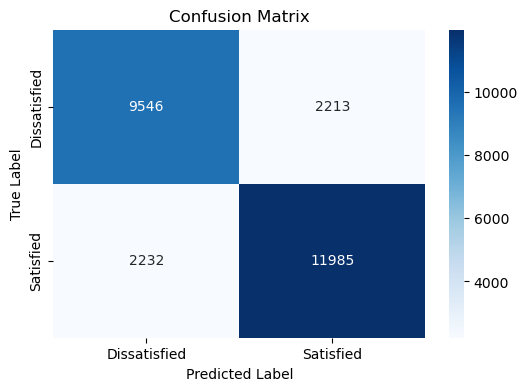

In [4]:
# Initialize and fit the Binomial Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probabilities for 'Satisfied'

# Performance Metrics Evaluation
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("--- Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (Out of all predicted satisfied, how many actually were?)")
print(f"Recall:    {recall:.4f}     (Out of all actually satisfied, how many did we catch?)")

# Display the Confusion Matrix cleanly
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dissatisfied', 'Satisfied'], yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [5]:
# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("--- Feature Coefficients (Top Drivers of Satisfaction) ---")
print(coefficients)

--- Feature Coefficients (Top Drivers of Satisfaction) ---
                              Feature  Coefficient
9              Inflight entertainment     0.972905
0                       Customer Type     0.725012
4                        Seat comfort     0.392582
12                   On-board service     0.387346
15                    Checkin service     0.355612
2                      Type of Travel     0.349626
11             Ease of Online booking     0.334382
13                   Leg room service     0.308623
17                    Online boarding     0.181621
7                       Gate location     0.162930
10                     Online support     0.144692
14                   Baggage handling     0.109271
18         Departure Delay in Minutes     0.073041
16                        Cleanliness     0.064025
8               Inflight wifi service    -0.127214
1                                 Age    -0.132652
3                     Flight Distance    -0.181013
21                     